In [1]:
import numpy as np
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print(f"Full dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Fetching MNIST dataset (this may take a moment)...
Full dataset shape: (70000, 784)
Labels shape: (70000,)


In [3]:
# Use 30,000 for training, 5,000 for testing
# Shuffle first so we get a representative subset
np.random.seed(42)
indices = np.random.permutation(len(X))

train_idx = indices[:30000]
test_idx  = indices[30000:35000]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (30000, 784)
Test set:     (5000, 784)


In [4]:
# Scale features (required for SGD and KNN but does not hurt other models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Part 1 — Implementation

## Training Models

In [15]:
results = {}  # Store accuracy and training time for all models

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    results[name] = {'accuracy': acc, 'train_time': round(train_time, 1)}
    print(f"{name:<30} Accuracy: {acc:.3f}   Train time: {train_time:.1f}s")
    return model

In [16]:
# Random Forest Classifier
rf_clf = evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

# KNN
knn_clf = evaluate(
    "K-Nearest Neighbors (k=5)",
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_train_scaled, y_train, X_test_scaled, y_test
)

# SGD Classifier
sgd_clf = evaluate(
    "SGD Classifier",
    SGDClassifier(max_iter=500, tol=0.01, random_state=42, n_jobs=-1),
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Naive Bayes Classifier
nb_clf = evaluate(
    "Naive Bayes (Gaussian)",
    GaussianNB(),
    X_train, y_train, X_test, y_test  # raw pixels, no scaling
)

Random Forest                  Accuracy: 0.962   Train time: 1.8s
K-Nearest Neighbors (k=5)      Accuracy: 0.938   Train time: 0.0s
SGD Classifier                 Accuracy: 0.912   Train time: 4.5s
Naive Bayes (Gaussian)         Accuracy: 0.568   Train time: 0.2s


In [17]:
estimators_hard = [
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ('sgd', SGDClassifier(max_iter=500, tol=0.01, random_state=42)),
    ('nb',  GaussianNB()),
]

hard_voting_clf = evaluate(
    "Hard Voting Ensemble",
    VotingClassifier(estimators=estimators_hard, voting='hard', n_jobs=-1),
    X_train, y_train, X_test, y_test  # raw pixels for everyone
)

Hard Voting Ensemble           Accuracy: 0.956   Train time: 34.4s


In [18]:
from sklearn.calibration import CalibratedClassifierCV

estimators_soft = [
    ('rf',  RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ('sgd', CalibratedClassifierCV(SGDClassifier(max_iter=500, tol=0.01, random_state=42))),
    ('nb',  GaussianNB()),
]

soft_voting_clf = evaluate(
    "Soft Voting Ensemble",
    VotingClassifier(estimators=estimators_soft, voting='soft', n_jobs=-1),
    X_train, y_train, X_test, y_test  # raw pixels for everyone
)

Soft Voting Ensemble           Accuracy: 0.946   Train time: 111.0s


## Evaluationg Results

In [19]:
    import pandas as pd

    df = pd.DataFrame(results).T
    df.index.name = 'Model'
    df['accuracy'] = df['accuracy'].apply(lambda x: f"{float(x):.4f}")
    df.columns = ['Test Accuracy', 'Train Time (s)']
    df = df.sort_values('Test Accuracy', ascending=False)

    print("\n====== Model Comparison ======")
    print(df.to_string())


====== Model Comparison ======
                          Test Accuracy  Train Time (s)
Model                                                  
Random Forest                    0.9624             1.8
Hard Voting Ensemble             0.9564            34.4
Soft Voting Ensemble             0.9462           111.0
K-Nearest Neighbors (k=5)        0.9382             0.0
SGD Classifier                   0.9118             4.5
Naive Bayes (Gaussian)           0.5684             0.2


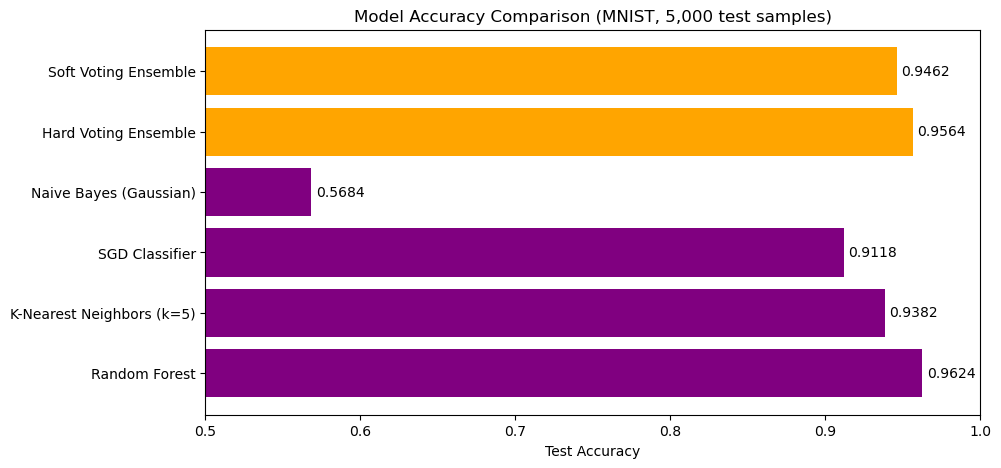

In [20]:
import matplotlib.pyplot as plt

names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]

colors = ['orange' if 'Ensemble' in n else 'purple' for n in names]

plt.figure(figsize=(10, 5))
bars = plt.barh(names, accs, color=colors)
plt.xlabel('Test Accuracy')
plt.title('Model Accuracy Comparison (MNIST, 5,000 test samples)')
plt.xlim(0.5, 1.0)
for bar, acc in zip(bars, accs):
    plt.text(acc + 0.003, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=10)

---
# Part 2 — Reflection & Summary

### What I Learned About Ensemble Learning

Ensemble learning combines multiple models to produce a stronger overall predictor. The intuition is that even if individual classifiers make different mistakes, the majority vote or averaged probability tends to cancel out the errors. This is particularly effective when the base models are **diverse** (meaning, they make uncorrelated errors).

Two common voting strategies were explored:
- Hard voting: Each model casts a single vote (its predicted class), and the majority wins.
- Soft voting: Models contribute class *probabilities*, which are averaged before picking the class.

### When Ensembles Are Beneficial

- When individual models are making **comparable but different** errors.
- When any single model has high variance ensamble models can help reduce this variance.
- When we can use extra computation at training time, but need more reliable predictions.
- Less beneficial when one model is already dominant and the others are much weaker — a weak model can drag down the ensemble.

### Observations & Surprises

- Instead of performing cross-validation to optimize the hyperparameters of the individual models, we can use ensembles of these to improve the accuracy.
- **KNN performed decently well**, reflecting the spatial structure of handwritten digits.
- **Naive Bayes was the weakest** individual model, which I think is expected. The conditional independence assumption is violated in image data where adjacent pixels are highly correlated.
- **Hard voting outperformed soft voting**, which is particularly interesting for me, because as per my intuition soft voting should be more accurate. Maybe this is because that the probability estimates from the naive bayes model were poor, reducing the benefit of soft voting.
- The **ensemble did not always beat the best individual model**. When Naive Bayes pulls the ensemble down, the gain from combining RF and KNN can be offset. This shows that blindly adding weak classifiers to an ensemble is not always beneficial.
- **Random Forest was the standout individual model**, which makes sense. It is itself an ensemble of many decision trees, so it already benefits from internal diversity.